In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', None)      # عرض كل الصفوف
pd.set_option('display.max_columns', None)   # عرض كل الأعمدة
pd.set_option('display.width', None)         # يمنع لفّ السطور
pd.set_option('display.max_colwidth', None)

In [3]:
deco=pd.read_excel("Dataset for Data Analytics.xlsx")
deco.head(10)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04
5,ORD200005,2023-10-23,C37249,Phone,2,245.86,934 Main St,Credit Card,Shipped,TRK72976927,4,SAVE10,Instagram,491.72
6,ORD200006,2025-06-17,C83492,Laptop,1,664.42,986 Main St,Gift Card,Returned,TRK96417362,6,SAVE10,Facebook,664.42
7,ORD200007,2023-05-12,C41460,Monitor,5,149.55,706 Main St,Cash,Shipped,TRK78809193,9,FREESHIP,Facebook,747.75
8,ORD200008,2025-04-02,C26817,Phone,2,134.28,904 Main St,Gift Card,Cancelled,TRK61042692,2,NaN,Email,268.56
9,ORD200009,2023-11-21,C31946,Desk,4,509.38,102 Main St,Credit Card,Shipped,TRK33478363,6,SAVE10,Google,2037.52



The dataset was cleaned using Excel. There were no duplicate records or missing values identified in the data. The only preprocessing step performed was adjusting the data types of certain columns to ensure consistency and proper analysis.
The only column containing null values is "CouponCode", which is expected and acceptable, as not all customers use coupons during their purchases.

In [4]:
deco.info()
print(deco.shape)
print(deco.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

## Basic Statistics

In [5]:
print(deco.describe())

                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558


> The dataset contains 1200 records.  
> The average quantity is 2.94 items per order.  
> The average total price is 1053.96.  
> The maximum total price reaches 3456.40 indicating high-value orders.

In [6]:
print("Mean values:")
print(deco[[ 'Date', 'Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].mean())
print("Median values:")
print(deco[['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']].median())

Mean values:
Date           2024-03-22 16:58:48
Quantity                  2.945833
UnitPrice                356.41275
ItemsInCart                  5.485
TotalPrice               1053.9683
dtype: object
Median values:
Quantity         3.000
UnitPrice      364.210
ItemsInCart      5.000
TotalPrice     823.615
dtype: float64


The distribution of the variables ('Quantity', 'UnitPrice', 'ItemsInCart') seems to be normally distributed ... indicating a balanced dataset without strong outliers
However the mean of 'TotalPrice' ='1053.9' is higher than its median = '823.615' which means that there are high values that slightly skew the observations

## let's take a closer look at the outlier

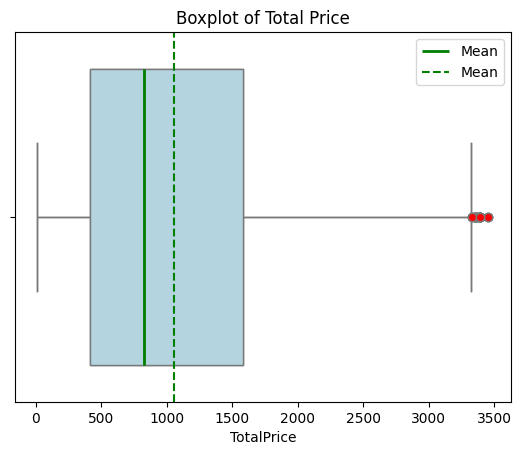

In [7]:

sns.boxplot(x=deco['TotalPrice'])
plt.title("Boxplot of Total Price")

sns.boxplot(x=deco['TotalPrice'] ,color='lightblue',
    medianprops={
        'color': 'green',
        'linewidth': 2 ,
        'label':'Mean'
    },
    
flierprops={
        'marker': 'o',
        'markerfacecolor': 'red',
        'markersize': 6,
        'linestyle': 'none'
    }

)

mean = deco['TotalPrice'].mean()
plt.axvline(mean, color='green', linestyle='--', label='Mean')

plt.legend()

plt.show()



The boxplot illustrates the distribution of TotalPrice, where most values fall within a moderate range between 500 and 1500.
The green line representing the median is approximately at 800, indicating that half of the orders have a total price below this value, while the other half exceed it.
A few points appear on the far right, representing high-value outliers. These outliers are not considered errors; rather, they reflect legitimate transactions where customers purchased expensive items or larger quantities.
The presence of these high-value orders slightly increases the mean compared to the median.
Therefore, these values were retained in the dataset as they provide valuable insights into customer purchasing behavior.

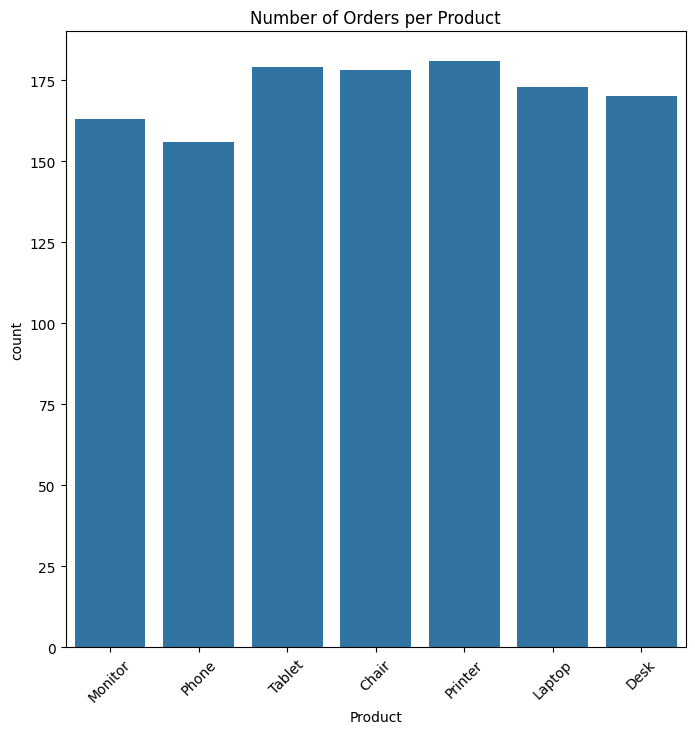

In [8]:
plt.figure(figsize=(8,8))
sns.countplot(x='Product', data=deco)
plt.title("Number of Orders per Product")
plt.xticks(rotation=45)
plt.show()


In [9]:
# عدد الطلبات حسب الحالة
print(deco['OrderStatus'].value_counts())

# عدد الطلبات حسب المنتج
print(deco['Product'].value_counts())

# إجمالي الأسعار مع الوقت
print(deco.groupby('Date')['TotalPrice'].sum())


OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64
Date
2023-01-01    2021.11
2023-01-02    1323.55
2023-01-03     897.70
2023-01-04    3629.54
2023-01-05    3642.30
2023-01-06    1524.36
2023-01-07    2398.12
2023-01-08    2748.37
2023-01-10     996.28
2023-01-11    1910.78
2023-01-12    3219.45
2023-01-13    1232.64
2023-01-14    2762.76
2023-01-15    1898.76
2023-01-18    1739.60
2023-01-20    4428.09
2023-01-22    2870.75
2023-01-23    2512.33
2023-01-24    2267.34
2023-01-25    2644.50
2023-01-26     788.32
2023-01-28    4568.82
2023-01-29    1315.32
2023-01-31    3344.96
2023-02-02    1260.42
2023-02-03    2445.04
2023-02-04     364.80
2023-02-05     333.93
2023-02-06     131.61
2023-02-08     590.87
2023-02-10    1806.72
2023-02-11    5601.89
2023-02-14     258.76
2023-02

## Check order status

C:\Users\SEYAD\AppData\Local\Temp\ipykernel_18096\2778803910.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='OrderStatus', data=deco, palette='Set2')


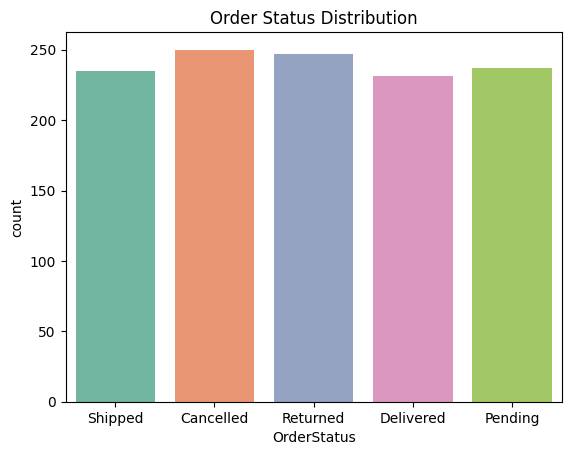

In [ ]:
sns.countplot(x='OrderStatus', data=deco, palette='Set2')
plt.title("Order Status")
plt.show()

>The distribution shows that cancelled and returned orders are relatively high compared to delivered orders.this indicates inefficiencies in the order process and potential customer dissatisfaction.improving order completion and reducing cancellations could significantly increase revenue

C:\Users\SEYAD\AppData\Local\Temp\ipykernel_18096\2386702708.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PaymentMethod', data=deco, palette='Set3')


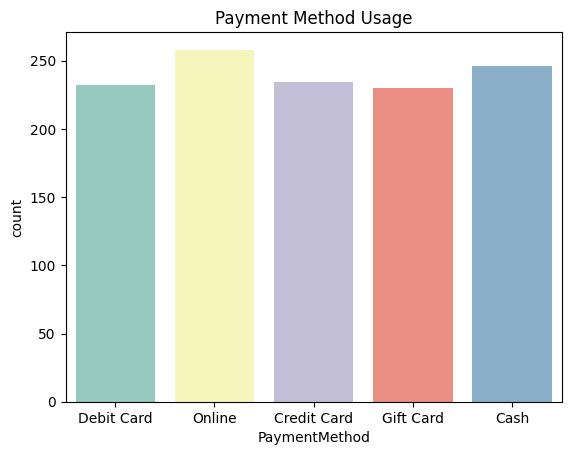

In [11]:

sns.countplot(x='PaymentMethod', data=deco, palette='Set3')
plt.title("Payment Method Usage")
plt.show()


>the graph shows that all payment are used among diffrent types of customers which is a good thing for the store to serve diffrent payment methods However, to gain more accurate business insights... it is important to analyze payment methods based only on delivered orders since they represent actual completed sales also we need to check the relation between payment methods & order status to identify if certain payment types are associated with higher cancellation or return rates

In [33]:
delivered_orders = deco[deco['OrderStatus'] == 'Delivered'] #We filter the dataset to include only delivered orders

total_sales = delivered_orders['TotalPrice'].sum()

print(total_sales)

242600.32


C:\Users\SEYAD\AppData\Local\Temp\ipykernel_18096\1623532871.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='PaymentMethod', data=delivered_orders, palette='Set3')


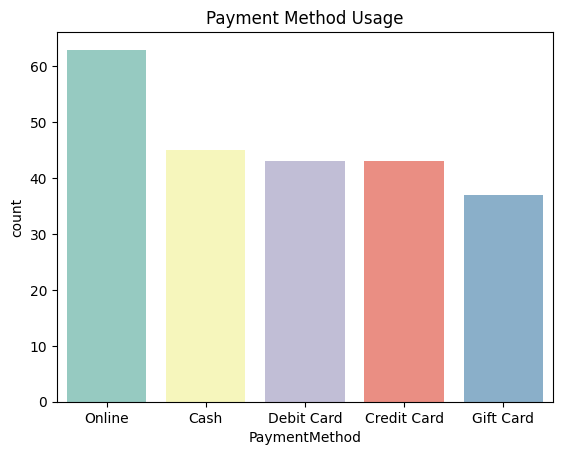

In [34]:
sns.countplot(x='PaymentMethod', data=delivered_orders, palette='Set3')
plt.title("Payment Method Usage")
plt.show()

In [40]:
pd.crosstab(deco['PaymentMethod'], deco['OrderStatus'], normalize='index').round(2)

OrderStatus,Cancelled,Delivered,Pending,Returned,Shipped
PaymentMethod,,,,,
Cash,0.20,0.18,0.21,0.23,0.17
Credit Card,0.23,0.18,0.21,0.21,0.17
Debit Card,0.19,0.19,0.24,0.22,0.17
Gift Card,0.22,0.16,0.15,0.23,0.24
Online,0.21,0.24,0.18,0.15,0.22


>The analysis shows that the relationship between payment methods and order status is relatively weak,as the distribution of order outcomes is similar across all payment types.This suggests that the payment method does not significantly influence whether an order is delivered,cancelled or returned

## check the sales per year

In [32]:

delivered_orders['Year'] = delivered_orders['Date'].dt.year #We extract the year from the 'Date' column and create a new 'Year' column
delivered_orders['Month'] = delivered_orders['Date'].dt.month #We extract the month from the 'Date' column and create a new 'Month' column
monthly_profit = delivered_orders.groupby(['Year', 'Month'])['TotalPrice'].sum().reset_index()
pivot_table = monthly_profit.pivot(index='Month', columns='Year', values='TotalPrice')




C:\Users\SEYAD\AppData\Local\Temp\ipykernel_18096\111898398.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders['Year'] = delivered_orders['Date'].dt.year #We extract the year from the 'Date' column and create a new 'Year' column
C:\Users\SEYAD\AppData\Local\Temp\ipykernel_18096\111898398.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders['Month'] = delivered_orders['Date'].dt.month #We extract the month from the 'Date' column and create a new 'Month' column


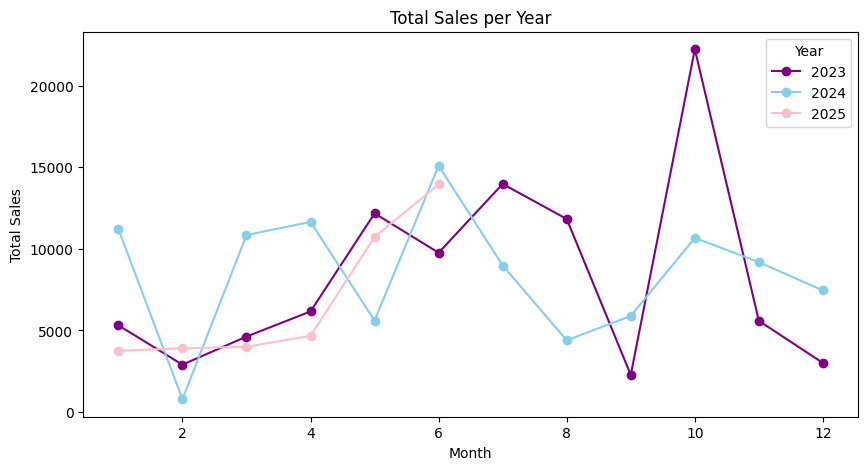

In [29]:
pivot_table.plot(figsize=(10,5), marker='o', color=['purple', 'skyblue', 'Pink'])

plt.title("Total Sales per Year")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()


Unfortunately,the sales aren't stable across months or years which means that demand is not stable and possible external factors affecting performance,with noticeable peaks in mid-year and occasional sharp increases or drops
>2023: rises around July

>2024: highest point in June (~15000)

>2025: clear rise until June (~14000)

So,There is Seasonality in the middle of the year

While 2025 demonstrates an upward trend, the overall pattern suggests strong seasonality and potential opportunities to optimize low-performing months.



## Check the relation between Quantity & Sales

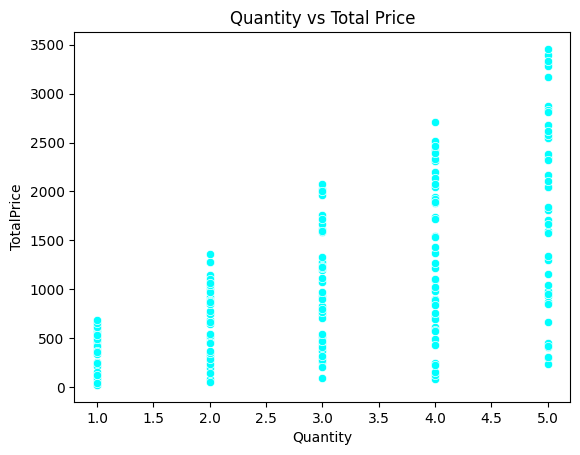

In [ ]:
sns.scatterplot(x='Quantity', y='TotalPrice', data=delivered_orders, color='Cyan') #total price of delivered orders only
plt.title("Quantity vs Total Price")
plt.show()

>There is a strong positive relationship between quantity and total price. However, the wide variation within each quantity level indicates that product price differences significantly influence total sales.

## Distribution of Total price
> How much is paid per order ?

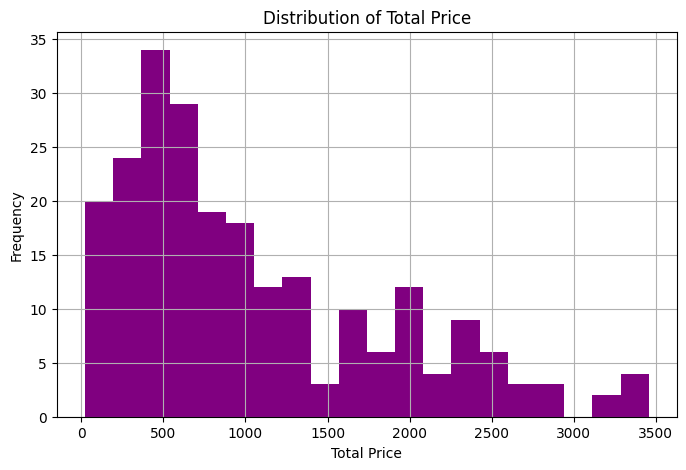

In [30]:
plt.figure(figsize=(8,5))

delivered_orders['TotalPrice'].hist(bins=20, color='purple') 
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")  
plt.ylabel("Frequency")    

plt.show()

>The distribution of total price is right-skewed,indicating that most transactions are low-value while a small number of high-value transactions exist.the majority of orders fall below 1000,suggesting that customers tend to make smaller purchases.However,the presence of high-value orders represents an opportunity to increase revenue by encouraging higher spending through promotions and bundling strategies